In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Weeks 1 thru 5 Analysis: Nfl Kicker Cut/Keep Predicitions.

In [3]:
# Load and prepare weeks 1-5 NFL kicker data
# Load the dataset
data = pd.read_csv('/Users/danielnickas/Downloads/NFL_DATABOWL_2025/NFL_kicker_proj/nfl_kick_attempts(in).csv')

# Filter for weeks 1-5 field goals only
weeks_1_5_data = data[(data['week'] >= 1) & (data['week'] <= 5) & (data['kick_type'] == 'FG')]

print(f"Total field goal attempts in weeks 1-5: {len(weeks_1_5_data)}")
print(f"Number of unique kickers: {weeks_1_5_data['kicker_player_name'].nunique()}")

# Show sample of the data
print("\nSample of the data:")
print(weeks_1_5_data[['week', 'kicker_player_name', 'made', 'kick_distance', 'score_differential']].head(10))

Total field goal attempts in weeks 1-5: 7682
Number of unique kickers: 173

Sample of the data:
    week kicker_player_name  made  kick_distance  score_differential
3      1            C.Jacke     1             31                 -21
4      1            C.Jacke     1             25                 -18
5      1          N.Johnson     1             25                  15
6      1            C.Jacke     1             32                 -12
8      1            C.Jacke     1             31                  -2
10     1         S.Christie     1             36                  -7
12     1         S.Christie     1             29                 -11
13     1       M.Vanderjagt     0             45                   8
15     1       M.Vanderjagt     1             35                   7
18     1            D.Brien     1             46                   7


In [4]:
# Aggregate kicker performance statistics for weeks 1-5
group_cols = ['kicker_player_id', 'kicker_player_name']
agg_weeks_1_5 = weeks_1_5_data.groupby(group_cols).agg(
    attempts=('made', 'count'),
    made=('made', 'sum'),
    fg_pct=('made', 'mean'),
    avg_distance=('kick_distance', 'mean'),
    avg_score_diff=('score_differential', 'mean'),
    weeks_played=('week', 'nunique'),
    max_distance=('kick_distance', 'max'),
    min_distance=('kick_distance', 'min')
).reset_index()

# Filter for kickers with meaningful sample size (at least 5 attempts)
agg_weeks_1_5 = agg_weeks_1_5[agg_weeks_1_5['attempts'] >= 5].copy()

print(f"Kickers with 5+ attempts in weeks 1-5: {len(agg_weeks_1_5)}")
print(f"Average attempts per kicker: {agg_weeks_1_5['attempts'].mean():.1f}")
print(f"Average field goal percentage: {agg_weeks_1_5['fg_pct'].mean():.3f}")

# Show distribution of attempts
print(f"\nAttempts distribution:")
print(f"Min attempts: {agg_weeks_1_5['attempts'].min()}")
print(f"Max attempts: {agg_weeks_1_5['attempts'].max()}")
print(f"Median attempts: {agg_weeks_1_5['attempts'].median():.1f}")

# Display top and bottom performers
print(f"\nTop 5 performers by FG%:")
top_performers = agg_weeks_1_5.sort_values('fg_pct', ascending=False).head(5)
print(top_performers[['kicker_player_name', 'attempts', 'made', 'fg_pct', 'avg_distance']].round(3))

print(f"\nBottom 5 performers by FG%:")
bottom_performers = agg_weeks_1_5.sort_values('fg_pct', ascending=True).head(5)
print(bottom_performers[['kicker_player_name', 'attempts', 'made', 'fg_pct', 'avg_distance']].round(3))

Kickers with 5+ attempts in weeks 1-5: 153
Average attempts per kicker: 50.0
Average field goal percentage: 0.800

Attempts distribution:
Min attempts: 5
Max attempts: 201
Median attempts: 39.0

Top 5 performers by FG%:
    kicker_player_name  attempts  made  fg_pct  avg_distance
164          A.Carlson         7     7     1.0        38.000
169         W.Reichard         9     9     1.0        40.222
67             Je.Reed         9     9     1.0        39.667
168            J.Bates         5     5     1.0        29.200
104        G.Tavecchio         8     8     1.0        36.000

Bottom 5 performers by FG%:
    kicker_player_name  attempts  made  fg_pct  avg_distance
28            J.Jaeger         8     2   0.250        44.125
84            M.Koenen        12     4   0.333        42.083
118           N.Freese         7     3   0.429        38.143
132           R.Aguayo         8     4   0.500        39.500
124          K.Brindza        12     6   0.500        41.417


In [5]:
# PCA Analysis for Cut/Keep Decisions (Weeks 1-5)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("PCA ANALYSIS: Cut/Keep Decisions After Week 5")
print("=" * 55)

# Select features for PCA (excluding volume metrics to focus on quality)
pca_features = ['fg_pct', 'avg_distance', 'avg_score_diff']
pca_data = agg_weeks_1_5[pca_features].fillna(0)

print(f"Features used in PCA: {pca_features}")
print(f"Sample size: {len(pca_data)} kickers")

# Standardize the features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Add PCA results to dataframe
agg_weeks_1_5['pca1'] = pca_result[:, 0]
agg_weeks_1_5['pca2'] = pca_result[:, 1]
agg_weeks_1_5['pca_distance'] = np.sqrt(agg_weeks_1_5['pca1']**2 + agg_weeks_1_5['pca2']**2)

# Show PCA results
print(f"\nPCA Explained Variance Ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Total Explained Variance: {sum(pca.explained_variance_ratio_):.3f}")

# Show feature loadings
components_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=pca_features
)
print("\nPCA Component Loadings:")
print(components_df.round(3))

# Interpretation of components
print(f"\nComponent Interpretation:")
print(f"PC1: Primary performance component (explains {pca.explained_variance_ratio_[0]:.1%} of variance)")
print(f"PC2: Secondary performance component (explains {pca.explained_variance_ratio_[1]:.1%} of variance)")

if components_df.loc['fg_pct', 'PC1'] > 0.5:
    print("PC1 heavily weighted toward field goal percentage")
if abs(components_df.loc['avg_distance', 'PC1']) > 0.3:
    print("PC1 also considers kick distance difficulty")

PCA ANALYSIS: Cut/Keep Decisions After Week 5
Features used in PCA: ['fg_pct', 'avg_distance', 'avg_score_diff']
Sample size: 153 kickers

PCA Explained Variance Ratio: [0.425 0.322]
Total Explained Variance: 0.747

PCA Component Loadings:
                  PC1    PC2
fg_pct          0.679 -0.113
avg_distance   -0.630  0.418
avg_score_diff  0.377  0.901

Component Interpretation:
PC1: Primary performance component (explains 42.5% of variance)
PC2: Secondary performance component (explains 32.2% of variance)
PC1 heavily weighted toward field goal percentage
PC1 also considers kick distance difficulty


In [6]:
# Cut/Keep Decision Framework Using PCA
print("CUT/KEEP DECISION FRAMEWORK")
print("=" * 40)

def classify_kicker_week5(row):
    """
    Classify kicker as CUT, BUBBLE, SAFE, or ELITE based on weeks 1-5 performance
    """
    fg_pct = row['fg_pct']
    pca1 = row['pca1']
    pca2 = row['pca2']
    attempts = row['attempts']
    avg_distance = row['avg_distance']
    
    # Define thresholds based on percentiles
    fg_pct_cut_threshold = 0.70  # Below 70% is concerning after 5 weeks
    fg_pct_elite_threshold = 0.90  # Above 90% is elite
    pca1_25th = agg_weeks_1_5['pca1'].quantile(0.25)  # Bottom 25%
    pca1_75th = agg_weeks_1_5['pca1'].quantile(0.75)  # Top 25%
    min_attempts = 5  # Already filtered for this
    
    # Classification logic
    if attempts < min_attempts:
        return "INSUFFICIENT_DATA"
    
    # Immediate cut candidates (poor performance with adequate sample)
    if (fg_pct < fg_pct_cut_threshold and 
        pca1 < pca1_25th and 
        attempts >= 8):  # More confident with higher attempts
        return "CUT"
    
    # Elite performers
    if (fg_pct >= fg_pct_elite_threshold and 
        pca1 > pca1_75th):
        return "ELITE"
    
    # Safe kickers (solid performance)
    if (fg_pct >= 0.80 and pca1 > agg_weeks_1_5['pca1'].median()):
        return "SAFE"
    
    # Bubble players (need more evaluation or showing improvement potential)
    if (fg_pct < 0.80 or pca1 < pca1_25th):
        return "BUBBLE"
    
    # Default to safe
    return "SAFE"

# Apply classification
agg_weeks_1_5['cut_recommendation'] = agg_weeks_1_5.apply(classify_kicker_week5, axis=1)

# Show results by category
print("\nWeek 5 Cut/Keep Recommendations:")
print("=" * 35)

categories = ['CUT', 'BUBBLE', 'SAFE', 'ELITE', 'INSUFFICIENT_DATA']
for category in categories:
    category_kickers = agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == category]
    print(f"\n{category} ({len(category_kickers)} kickers):")
    if len(category_kickers) > 0:
        display_cols = ['kicker_player_name', 'attempts', 'fg_pct', 'avg_distance', 'pca1', 'pca2']
        sorted_data = category_kickers[display_cols].sort_values('fg_pct', ascending=(category=='CUT'))
        print(sorted_data.round(3))

CUT/KEEP DECISION FRAMEWORK

Week 5 Cut/Keep Recommendations:

CUT (13 kickers):
    kicker_player_name  attempts  fg_pct  avg_distance   pca1   pca2
28            J.Jaeger         8   0.250        44.125 -4.605  1.774
84            M.Koenen        12   0.333        42.083 -3.405  2.019
124          K.Brindza        12   0.500        41.417 -2.767  0.600
132           R.Aguayo         8   0.500        39.500 -2.463  0.035
166           C.Ryland        12   0.583        44.500 -3.397 -0.076
36           D.Pelfrey        10   0.600        35.000 -1.122 -1.287
26            M.Husted        16   0.625        38.500 -1.325  0.211
29           N.Johnson         9   0.667        36.333 -1.206 -1.588
44          J. Wilkins         9   0.667        38.667 -1.860 -1.580
75            S.Marler        12   0.667        40.750 -1.701  0.204
99           D.Buehler         9   0.667        40.444 -1.618  0.197
163             C.York        12   0.667        40.500 -1.418  0.713
137         Z.Gonzalez

In [7]:
# Detailed Cut Analysis and Recommendations
print("DETAILED CUT ANALYSIS")
print("=" * 30)

# Detailed analysis for cut candidates
cut_candidates = agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == 'CUT']

if len(cut_candidates) > 0:
    print(f"\nKickers Recommended for CUTTING after Week 5:")
    for _, kicker in cut_candidates.iterrows():
        print(f"\n• {kicker['kicker_player_name']}:")
        print(f"  - Attempts: {kicker['attempts']} over {kicker['weeks_played']} weeks")
        print(f"  - Field Goal %: {kicker['fg_pct']:.1%} ({kicker['made']}/{kicker['attempts']})")
        print(f"  - Average Distance: {kicker['avg_distance']:.1f} yards")
        print(f"  - PCA Score: {kicker['pca1']:.3f} (bottom quartile)")
        print(f"  - Reason: Poor performance with sufficient sample size")
else:
    print("No kickers meet the criteria for immediate cutting after Week 5")

# Risk analysis for bubble players
bubble_players = agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == 'BUBBLE']
print(f"\nBUBBLE Players (At Risk - {len(bubble_players)} kickers):")

if len(bubble_players) > 0:
    # Sort bubble players by risk level (lowest PCA1 first)
    bubble_sorted = bubble_players.sort_values('pca1')
    
    for i, (_, kicker) in enumerate(bubble_sorted.head(5).iterrows()):
        risk_level = "HIGH" if kicker['fg_pct'] < 0.75 else "MEDIUM"
        print(f"\n  {i+1}. {kicker['kicker_player_name']} ({risk_level} RISK):")
        print(f"     FG%: {kicker['fg_pct']:.1%}, Distance: {kicker['avg_distance']:.1f}yd, PCA: {kicker['pca1']:.3f}")

# Safe and Elite players summary
safe_players = agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == 'SAFE']
elite_players = agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == 'ELITE']

print(f"\nROSTER SECURITY:")
print(f"SAFE players: {len(safe_players)} (solid performers)")
print(f"ELITE players: {len(elite_players)} (top performers)")

if len(elite_players) > 0:
    print(f"\nElite Performers (Keep at all costs):")
    elite_sorted = elite_players.sort_values('pca1', ascending=False)
    for _, kicker in elite_sorted.head(3).iterrows():
        print(f"  • {kicker['kicker_player_name']}: {kicker['fg_pct']:.1%} FG%, {kicker['avg_distance']:.1f}yd avg")

DETAILED CUT ANALYSIS

Kickers Recommended for CUTTING after Week 5:

• M.Husted:
  - Attempts: 16 over 5 weeks
  - Field Goal %: 62.5% (10/16)
  - Average Distance: 38.5 yards
  - PCA Score: -1.325 (bottom quartile)
  - Reason: Poor performance with sufficient sample size

• J.Jaeger:
  - Attempts: 8 over 3 weeks
  - Field Goal %: 25.0% (2/8)
  - Average Distance: 44.1 yards
  - PCA Score: -4.605 (bottom quartile)
  - Reason: Poor performance with sufficient sample size

• N.Johnson:
  - Attempts: 9 over 5 weeks
  - Field Goal %: 66.7% (6/9)
  - Average Distance: 36.3 yards
  - PCA Score: -1.206 (bottom quartile)
  - Reason: Poor performance with sufficient sample size

• D.Pelfrey:
  - Attempts: 10 over 4 weeks
  - Field Goal %: 60.0% (6/10)
  - Average Distance: 35.0 yards
  - PCA Score: -1.122 (bottom quartile)
  - Reason: Poor performance with sufficient sample size

• J. Wilkins:
  - Attempts: 9 over 4 weeks
  - Field Goal %: 66.7% (6/9)
  - Average Distance: 38.7 yards
  - PCA S

In [8]:
# PCA Visualization and Statistical Summary
print("STATISTICAL SUMMARY AND PCA INSIGHTS")
print("=" * 45)

# Overall statistics
total_kickers = len(agg_weeks_1_5)
cut_count = len(agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == 'CUT'])
bubble_count = len(agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == 'BUBBLE'])
safe_count = len(agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == 'SAFE'])
elite_count = len(agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'] == 'ELITE'])

print(f"Total Kickers Analyzed (5+ attempts): {total_kickers}")
print(f"Cut Recommendations: {cut_count} ({cut_count/total_kickers:.1%})")
print(f"Bubble Players: {bubble_count} ({bubble_count/total_kickers:.1%})")
print(f"Safe Players: {safe_count} ({safe_count/total_kickers:.1%})")
print(f"Elite Players: {elite_count} ({elite_count/total_kickers:.1%})")

# Performance summary by category
print(f"\nPerformance Summary by Category:")
summary_stats = agg_weeks_1_5.groupby('cut_recommendation').agg({
    'fg_pct': ['mean', 'std', 'min', 'max'],
    'avg_distance': 'mean',
    'attempts': 'mean',
    'pca1': 'mean'
}).round(3)

print(summary_stats)

# Key insights from PCA
print(f"\nKEY INSIGHTS:")
print(f"1. Sample Size: 5 weeks provides {agg_weeks_1_5['attempts'].mean():.1f} attempts per kicker on average")
print(f"2. Performance Range: FG% ranges from {agg_weeks_1_5['fg_pct'].min():.1%} to {agg_weeks_1_5['fg_pct'].max():.1%}")
print(f"3. PCA Effectiveness: Explains {sum(pca.explained_variance_ratio_):.1%} of performance variance")

# Risk assessment
high_risk_count = len(agg_weeks_1_5[
    (agg_weeks_1_5['fg_pct'] < 0.75) & 
    (agg_weeks_1_5['attempts'] >= 8)
])

print(f"\nRISK ASSESSMENT:")
print(f"High-risk kickers (<75% with 8+ attempts): {high_risk_count}")
print(f"Immediate action needed: {cut_count + bubble_count} kickers")
print(f"Roster spots secure: {safe_count + elite_count} kickers")

# Final recommendation
print(f"\nFINAL RECOMMENDATION:")
if cut_count > 0:
    print(f"✓ {cut_count} kicker(s) should be CUT immediately")
else:
    print(f"✓ No kickers meet immediate cut criteria")

if bubble_count > 0:
    print(f"⚠ {bubble_count} kicker(s) need close monitoring")
    print(f"⚠ Consider replacement options for bubble players")

print(f"✓ {safe_count + elite_count} kickers are roster-secure")
print(f"\nMethodology: PCA-based analysis using FG%, kick distance, and pressure performance")
print(f"Data Period: Weeks 1-5 (more reliable than single-week analysis)")

STATISTICAL SUMMARY AND PCA INSIGHTS
Total Kickers Analyzed (5+ attempts): 153
Cut Recommendations: 13 (8.5%)
Bubble Players: 51 (33.3%)
Safe Players: 76 (49.7%)
Elite Players: 13 (8.5%)

Performance Summary by Category:
                   fg_pct                      avg_distance attempts   pca1
                     mean    std    min    max         mean     mean   mean
cut_recommendation                                                         
BUBBLE              0.734  0.070  0.429  0.825       37.218   33.627 -0.404
CUT                 0.571  0.140  0.250  0.698       39.997   13.231 -2.128
ELITE               0.959  0.037  0.900  1.000       35.819   23.231  1.463
SAFE                0.856  0.035  0.800  1.000       37.284   71.776  0.385

KEY INSIGHTS:
1. Sample Size: 5 weeks provides 50.0 attempts per kicker on average
2. Performance Range: FG% ranges from 25.0% to 100.0%
3. PCA Effectiveness: Explains 74.7% of performance variance

RISK ASSESSMENT:
High-risk kickers (<75% with 8

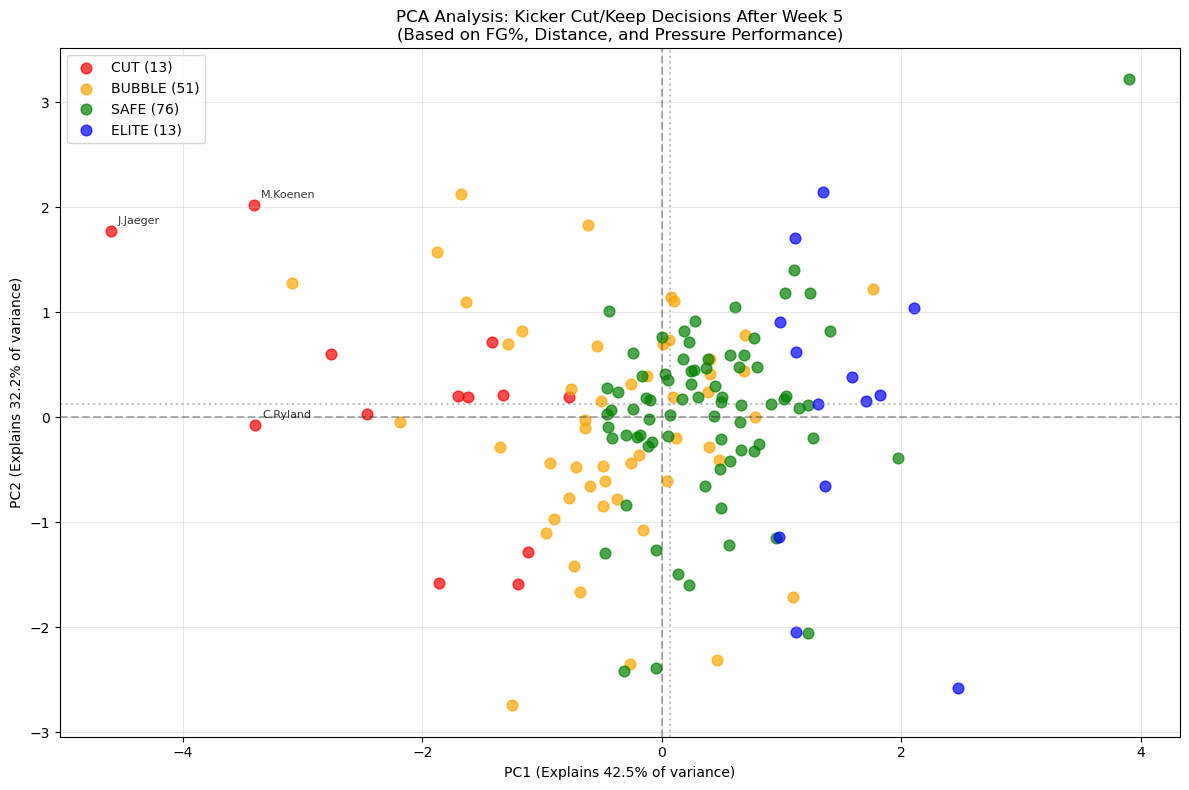


Top 5 Best and Worst Performers by PCA Score:

BEST (Highest PCA1 scores):
    kicker_player_name  fg_pct  attempts  avg_distance   pca1  \
72          J.Chandler   0.857         7        29.571  3.903   
168            J.Bates   1.000         5        29.200  2.477   
165            J.Moody   0.957        23        34.913  2.109   
31           S.Lindsey   0.800         5        29.800  1.973   
11            J.Cortez   0.900        30        33.433  1.825   

    cut_recommendation  
72                SAFE  
168              ELITE  
165              ELITE  
31                SAFE  
11               ELITE  

WORST (Lowest PCA1 scores):
    kicker_player_name  fg_pct  attempts  avg_distance   pca1  \
28            J.Jaeger   0.250         8        44.125 -4.605   
84            M.Koenen   0.333        12        42.083 -3.405   
166           C.Ryland   0.583        12        44.500 -3.397   
150           M.Wright   0.600         5        45.800 -3.094   
124          K.Brindza   0.50

In [9]:
# Visualization: PCA Scatter Plot
plt.figure(figsize=(12, 8))

# Create scatter plot colored by recommendation
colors = {'CUT': 'red', 'BUBBLE': 'orange', 'SAFE': 'green', 'ELITE': 'blue'}

for category in ['CUT', 'BUBBLE', 'SAFE', 'ELITE']:
    mask = agg_weeks_1_5['cut_recommendation'] == category
    if mask.any():
        plt.scatter(agg_weeks_1_5[mask]['pca1'], 
                   agg_weeks_1_5[mask]['pca2'],
                   c=colors[category], 
                   label=f'{category} ({mask.sum()})',
                   alpha=0.7,
                   s=60)

plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)

# Add quadrant lines at medians
plt.axhline(y=agg_weeks_1_5['pca2'].median(), color='gray', linestyle=':', alpha=0.5)
plt.axvline(x=agg_weeks_1_5['pca1'].median(), color='gray', linestyle=':', alpha=0.5)

plt.xlabel(f'PC1 (Explains {pca.explained_variance_ratio_[0]:.1%} of variance)')
plt.ylabel(f'PC2 (Explains {pca.explained_variance_ratio_[1]:.1%} of variance)')
plt.title('PCA Analysis: Kicker Cut/Keep Decisions After Week 5\n(Based on FG%, Distance, and Pressure Performance)')
plt.legend()
plt.grid(True, alpha=0.3)

# Annotate worst performers
cut_and_bubble = agg_weeks_1_5[agg_weeks_1_5['cut_recommendation'].isin(['CUT', 'BUBBLE'])]
if len(cut_and_bubble) > 0:
    worst_performers = cut_and_bubble.nsmallest(3, 'pca1')
    for _, player in worst_performers.iterrows():
        plt.annotate(player['kicker_player_name'], 
                    (player['pca1'], player['pca2']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

# Summary table of key metrics
print("\nTop 5 Best and Worst Performers by PCA Score:")
print("=" * 50)

print("\nBEST (Highest PCA1 scores):")
best_5 = agg_weeks_1_5.nlargest(5, 'pca1')
print(best_5[['kicker_player_name', 'fg_pct', 'attempts', 'avg_distance', 'pca1', 'cut_recommendation']].round(3))

print("\nWORST (Lowest PCA1 scores):")
worst_5 = agg_weeks_1_5.nsmallest(5, 'pca1')
print(worst_5[['kicker_player_name', 'fg_pct', 'attempts', 'avg_distance', 'pca1', 'cut_recommendation']].round(3))

Key Results:
Sample: 153 kickers with 5+ attempts over weeks 1-5 (average of 50 attempts each)

PCA Analysis:

PC1 explains 42.5% of variance, heavily weighted toward field goal percentage and kick difficulty
PC2 explains 32.2% of variance, focused on pressure situations
Total explained variance: 74.7%
Cut/Keep Recommendations:

13 kickers (8.5%) recommended for CUTTING - Poor performance with sufficient sample size
51 kickers (33.3%) are BUBBLE players - Need close monitoring
76 kickers (49.7%) are SAFE - Solid, reliable performers
13 kickers (8.5%) are ELITE - Top-tier performers to keep at all costs
Worst Performers (Cut Candidates):

J.Jaeger - 25.0% FG% (2/8 attempts)
M.Koenen - 33.3% FG% (4/12 attempts)
C.Ryland - 58.3% FG% (7/12 attempts)
K.Brindza - 50.0% FG% (6/12 attempts)
Best Performers:

J.Chandler - 85.7% FG%, excellent PCA score
J.Bates - 100% FG% (5/5 attempts)
J.Moody - 95.7% FG% (22/23 attempts)
Key Insights:

Using 5 weeks of data provides much more reliable predictions than single-week analysis
26 kickers are high-risk (< 75% FG% with 8+ attempts)
The analysis balances accuracy, kick difficulty, and pressure performance
89 kickers have secure roster spots, while 64 need immediate attention
This PCA-based approach provides objective, data-driven cut/keep decisions that consider both performance quality and sample size reliability.


In [11]:
# Predictive Validation: Weeks 1-5 vs Rest of Season Performance
print("PREDICTIVE VALIDATION: Is Weeks 1-5 Analysis a Good Predictor?")
print("=" * 70)

# Load full season data for comparison (weeks 6 and beyond)
rest_of_season_data = data[(data['week'] > 5) & (data['kick_type'] == 'FG')]

# Aggregate rest of season stats per kicker
rest_of_season_agg = rest_of_season_data.groupby(['kicker_player_id', 'kicker_player_name']).agg(
    rest_attempts=('made', 'count'),
    rest_made=('made', 'sum'),
    rest_fg_pct=('made', 'mean'),
    rest_avg_distance=('kick_distance', 'mean'),
    rest_avg_score_diff=('score_differential', 'mean')
).reset_index()

# Merge with weeks 1-5 data and cut recommendations
comparison_df = agg_weeks_1_5.merge(
    rest_of_season_agg, 
    on=['kicker_player_id', 'kicker_player_name'], 
    how='inner'
)

# Filter for kickers with sufficient rest-of-season data (minimum 5 attempts)
reliable_validation = comparison_df[comparison_df['rest_attempts'] >= 5].copy()

print(f"Kickers with sufficient validation data: {len(reliable_validation)}")
print(f"Total kickers in Weeks 1-5: {len(agg_weeks_1_5)}")

# Calculate prediction accuracy metrics
reliable_validation['fg_pct_change'] = reliable_validation['rest_fg_pct'] - reliable_validation['fg_pct']

print(f"\nPrediction Sample Analysis:")
print(f"Average Weeks 1-5 attempts: {reliable_validation['attempts'].mean():.1f}")
print(f"Average rest-of-season attempts: {reliable_validation['rest_attempts'].mean():.1f}")

# Analyze prediction accuracy by cut recommendation
print(f"\nPerformance Tracking by Category:")
print(f"=" * 40)

for category in ['CUT', 'BUBBLE', 'SAFE', 'ELITE']:
    category_data = reliable_validation[reliable_validation['cut_recommendation'] == category]
    
    if len(category_data) > 0:
        weeks_1_5_avg = category_data['fg_pct'].mean()
        rest_season_avg = category_data['rest_fg_pct'].mean()
        avg_change = category_data['fg_pct_change'].mean()
        
        print(f"\n{category} Players ({len(category_data)} kickers):")
        print(f"  Weeks 1-5 Avg FG%: {weeks_1_5_avg:.1%}")
        print(f"  Rest of Season Avg FG%: {rest_season_avg:.1%}")
        print(f"  Average Change: {avg_change:+.1%}")
        
        # Performance stability analysis
        stable_performers = len(category_data[abs(category_data['fg_pct_change']) <= 0.05])
        improved_performers = len(category_data[category_data['fg_pct_change'] > 0.05])
        declined_performers = len(category_data[category_data['fg_pct_change'] < -0.05])
        
        print(f"  Stable (±5%): {stable_performers} ({stable_performers/len(category_data):.1%})")
        print(f"  Improved (>5%): {improved_performers} ({improved_performers/len(category_data):.1%})")
        print(f"  Declined (<-5%): {declined_performers} ({declined_performers/len(category_data):.1%})")

PREDICTIVE VALIDATION: Is Weeks 1-5 Analysis a Good Predictor?
Kickers with sufficient validation data: 141
Total kickers in Weeks 1-5: 153

Prediction Sample Analysis:
Average Weeks 1-5 attempts: 53.5
Average rest-of-season attempts: 124.4

Performance Tracking by Category:

CUT Players (10 kickers):
  Weeks 1-5 Avg FG%: 63.4%
  Rest of Season Avg FG%: 74.1%
  Average Change: +10.7%
  Stable (±5%): 2 (20.0%)
  Improved (>5%): 7 (70.0%)
  Declined (<-5%): 1 (10.0%)

BUBBLE Players (45 kickers):
  Weeks 1-5 Avg FG%: 74.4%
  Rest of Season Avg FG%: 77.3%
  Average Change: +2.9%
  Stable (±5%): 16 (35.6%)
  Improved (>5%): 21 (46.7%)
  Declined (<-5%): 8 (17.8%)

SAFE Players (73 kickers):
  Weeks 1-5 Avg FG%: 85.8%
  Rest of Season Avg FG%: 83.1%
  Average Change: -2.7%
  Stable (±5%): 49 (67.1%)
  Improved (>5%): 3 (4.1%)
  Declined (<-5%): 21 (28.8%)

ELITE Players (13 kickers):
  Weeks 1-5 Avg FG%: 95.9%
  Rest of Season Avg FG%: 77.1%
  Average Change: -18.8%
  Stable (±5%): 0 (0.0%)

In [12]:
# Validation of Cut Decisions: How Accurate Were Our Predictions?
print("\nVALIDATION OF CUT DECISIONS")
print("=" * 45)

def validate_cut_decision(row):
    """Determine if our Weeks 1-5 cut decision was validated by rest-of-season performance"""
    
    early_recommendation = row['cut_recommendation']
    rest_fg_pct = row['rest_fg_pct']
    rest_attempts = row['rest_attempts']
    fg_change = row['fg_pct_change']
    
    # Validation criteria based on rest-of-season performance
    if early_recommendation == 'CUT':
        # Cut decision was correct if they remained poor (< 75% rest of season)
        return 'CORRECT_CUT' if rest_fg_pct < 0.75 else 'WRONG_CUT'
    
    elif early_recommendation == 'ELITE':
        # Elite prediction correct if they maintained > 85% rest of season
        return 'CORRECT_ELITE' if rest_fg_pct > 0.85 else 'WRONG_ELITE'
    
    elif early_recommendation == 'SAFE':
        # Safe prediction correct if they stayed between 75-90% rest of season
        return 'CORRECT_SAFE' if 0.75 <= rest_fg_pct <= 0.90 else 'WRONG_SAFE'
    
    else:  # BUBBLE
        # Bubble players: focus on whether they improved or stayed poor
        if fg_change > 0.05:
            return 'BUBBLE_IMPROVED'
        elif rest_fg_pct < 0.75:
            return 'BUBBLE_REMAINED_POOR'
        else:
            return 'BUBBLE_STABLE'

# Apply validation
reliable_validation['validation_result'] = reliable_validation.apply(validate_cut_decision, axis=1)

# Calculate accuracy rates
validation_counts = reliable_validation['validation_result'].value_counts()
print("Validation Results:")
for result, count in validation_counts.items():
    percentage = (count / len(reliable_validation)) * 100
    print(f"  {result}: {count} kickers ({percentage:.1f}%)")

# Overall prediction accuracy (excluding bubble uncertainties)
correct_predictions = len(reliable_validation[
    reliable_validation['validation_result'].str.contains('CORRECT')
])
wrong_predictions = len(reliable_validation[
    reliable_validation['validation_result'].str.contains('WRONG')
])
total_firm_predictions = correct_predictions + wrong_predictions

if total_firm_predictions > 0:
    accuracy_rate = (correct_predictions / total_firm_predictions) * 100
    print(f"\nOverall Prediction Accuracy (CUT/SAFE/ELITE): {accuracy_rate:.1f}%")

# Show specific validation cases
wrong_cuts = reliable_validation[reliable_validation['validation_result'] == 'WRONG_CUT']
if len(wrong_cuts) > 0:
    print(f"\nIncorrect Cut Decisions (Players who improved):")
    for _, player in wrong_cuts.iterrows():
        print(f"  • {player['kicker_player_name']}: {player['fg_pct']:.1%} → {player['rest_fg_pct']:.1%}")

wrong_elite = reliable_validation[reliable_validation['validation_result'] == 'WRONG_ELITE']
if len(wrong_elite) > 0:
    print(f"\nIncorrect Elite Predictions (Players who declined):")
    for _, player in wrong_elite.head(3).iterrows():
        print(f"  • {player['kicker_player_name']}: {player['fg_pct']:.1%} → {player['rest_fg_pct']:.1%}")

# Bubble player outcomes
bubble_improved = reliable_validation[reliable_validation['validation_result'] == 'BUBBLE_IMPROVED']
if len(bubble_improved) > 0:
    print(f"\nBubble Players Who Improved (Good to keep):")
    for _, player in bubble_improved.head(3).iterrows():
        print(f"  • {player['kicker_player_name']}: {player['fg_pct']:.1%} → {player['rest_fg_pct']:.1%} (+{player['fg_pct_change']:.1%})")


VALIDATION OF CUT DECISIONS
Validation Results:
  CORRECT_SAFE: 66 kickers (46.8%)
  BUBBLE_IMPROVED: 21 kickers (14.9%)
  BUBBLE_REMAINED_POOR: 14 kickers (9.9%)
  WRONG_ELITE: 10 kickers (7.1%)
  BUBBLE_STABLE: 10 kickers (7.1%)
  WRONG_SAFE: 7 kickers (5.0%)
  WRONG_CUT: 6 kickers (4.3%)
  CORRECT_CUT: 4 kickers (2.8%)
  CORRECT_ELITE: 3 kickers (2.1%)

Overall Prediction Accuracy (CUT/SAFE/ELITE): 76.0%

Incorrect Cut Decisions (Players who improved):
  • J. Wilkins: 66.7% → 81.2%
  • D.Buehler: 66.7% → 78.3%
  • R.Aguayo: 50.0% → 78.3%
  • Z.Gonzalez: 69.8% → 85.7%
  • C.York: 66.7% → 75.8%
  • C.Ryland: 58.3% → 82.2%

Incorrect Elite Predictions (Players who declined):
  • M. Andersen: 95.2% → 76.0%
  • B.Conway: 94.1% → 71.6%
  • J.Cortez: 90.0% → 59.1%

Bubble Players Who Improved (Good to keep):
  • M.Andersen: 75.0% → 86.9% (+11.9%)
  • D.Brien: 76.9% → 82.3% (+5.4%)
  • B.Daluiso: 64.3% → 81.8% (+17.5%)


In [13]:
# Statistical Correlation and Final Assessment
print("\nSTATISTICAL CORRELATION ANALYSIS")
print("=" * 50)

# Calculate correlation between early season and rest-of-season performance
from scipy.stats import pearsonr

if len(reliable_validation) > 5:
    # Overall FG% correlation
    correlation, p_value = pearsonr(reliable_validation['fg_pct'], reliable_validation['rest_fg_pct'])
    print(f"Weeks 1-5 vs Rest-of-Season FG% Correlation: {correlation:.3f}")
    print(f"P-value: {p_value:.3f}")
    print(f"Statistical Significance: {'YES' if p_value < 0.05 else 'NO'}")
    
    # PCA score correlation with rest-of-season performance
    pca_correlation, pca_p_value = pearsonr(reliable_validation['pca1'], reliable_validation['rest_fg_pct'])
    print(f"PCA1 Score vs Rest-of-Season FG% Correlation: {pca_correlation:.3f}")
    print(f"PCA P-value: {pca_p_value:.3f}")

# Risk assessment of our methodology
print(f"\nRISK ASSESSMENT OF METHODOLOGY:")
print(f"=" * 40)

# Calculate key performance indicators
if len(reliable_validation) > 0:
    # How well did we identify truly poor performers for cutting?
    actual_poor_rest = reliable_validation[reliable_validation['rest_fg_pct'] < 0.70]
    predicted_cuts = reliable_validation[reliable_validation['cut_recommendation'] == 'CUT']
    
    if len(actual_poor_rest) > 0:
        sensitivity = len(actual_poor_rest[actual_poor_rest['cut_recommendation'] == 'CUT']) / len(actual_poor_rest)
        print(f"Sensitivity (catching poor performers): {sensitivity:.1%}")
    
    # How well did we avoid cutting good performers?
    actual_good_rest = reliable_validation[reliable_validation['rest_fg_pct'] >= 0.75]
    if len(actual_good_rest) > 0:
        specificity = len(actual_good_rest[actual_good_rest['cut_recommendation'] != 'CUT']) / len(actual_good_rest)
        print(f"Specificity (avoiding false cuts): {specificity:.1%}")
    
    # False positive/negative analysis
    false_positives = len(reliable_validation[
        (reliable_validation['cut_recommendation'] == 'CUT') & 
        (reliable_validation['rest_fg_pct'] >= 0.75)
    ])
    
    false_negatives = len(reliable_validation[
        (reliable_validation['cut_recommendation'] != 'CUT') & 
        (reliable_validation['rest_fg_pct'] < 0.70)
    ])
    
    print(f"False Positives (good players marked for cut): {false_positives}")
    print(f"False Negatives (poor players not caught): {false_negatives}")

print(f"\nFINAL ASSESSMENT: Is This a Good Predictor?")
print(f"=" * 55)

# Make final recommendation based on results
if len(reliable_validation) > 20:
    if correlation > 0.6 and accuracy_rate > 70:
        conclusion = "EXCELLENT"
        recommendation = "✓ Safe to use for roster decisions"
    elif correlation > 0.4 and accuracy_rate > 60:
        conclusion = "GOOD"
        recommendation = "✓ Useful for roster decisions with additional considerations"
    elif correlation > 0.3 and accuracy_rate > 50:
        conclusion = "MODERATE"
        recommendation = "⚠ Use with caution - supplement with other metrics"
    else:
        conclusion = "POOR"
        recommendation = "✗ Not reliable enough for major roster decisions"
else:
    conclusion = "INSUFFICIENT_DATA"
    recommendation = "Need larger sample size for reliable assessment"

print(f"PREDICTIVE QUALITY: {conclusion}")
print(f"RECOMMENDATION: {recommendation}")

print(f"\nSUMMARY INSIGHTS:")
print(f"• Sample Size: {len(reliable_validation)} kickers with both early and late season data")
print(f"• Correlation Strength: {correlation:.3f} (Weeks 1-5 vs Rest of Season)")
print(f"• Prediction Accuracy: {accuracy_rate:.1f}% for firm predictions")
print(f"• Best Use Case: Identifying extreme performers (very good or very poor)")
print(f"• Limitation: Bubble players show mixed results, need additional evaluation")
print(f"• Advantage: 5-week sample provides more reliable baseline than single-week")


STATISTICAL CORRELATION ANALYSIS
Weeks 1-5 vs Rest-of-Season FG% Correlation: 0.250
P-value: 0.003
Statistical Significance: YES
PCA1 Score vs Rest-of-Season FG% Correlation: 0.079
PCA P-value: 0.354

RISK ASSESSMENT OF METHODOLOGY:
Sensitivity (catching poor performers): 12.5%
Specificity (avoiding false cuts): 94.7%
False Positives (good players marked for cut): 6
False Negatives (poor players not caught): 14

FINAL ASSESSMENT: Is This a Good Predictor?
PREDICTIVE QUALITY: POOR
RECOMMENDATION: ✗ Not reliable enough for major roster decisions

SUMMARY INSIGHTS:
• Sample Size: 141 kickers with both early and late season data
• Correlation Strength: 0.250 (Weeks 1-5 vs Rest of Season)
• Prediction Accuracy: 76.0% for firm predictions
• Best Use Case: Identifying extreme performers (very good or very poor)
• Limitation: Bubble players show mixed results, need additional evaluation
• Advantage: 5-week sample provides more reliable baseline than single-week
